# Reconocimiento de Patrones
[Curso de Reconocimiento de Patrones](https://https://domingomery.ing.puc.cl/teaching/patrones/)

Departamento de Ciencia de la Computación

Universidad Catolica de Chile

(c) Domingo Mery, http://domingomery.ing.uc.cl



# EJERCICIO E03: SEGMENTACIÓN, CARACTERÍSTICAS GEOMÉTRICAS

El objetivo de este ejercicio es aprender las funciones básicas de procesamiento de segmentación y clasificación de objetos por su forma.

Con este fin se cuenta con una base de datos de 300 cubiertos (100 tenedores, 100 cuchillos y 100 cucharas) que debe ser clasificada usando las características geométricas basadas en decriptores de Fourier y momento de Hi.

<font color='red'>OJO: Para realizar este ejercicio **PUEDES** re-utilizar los código disponibles en el GitHub del curso o bien usar el código que quieras que encuentres googleando, o bien usando alguna IA. </font>

<font color='green'>Si usas IA, es importante que sepas bien lo que la IA está haciendo, de ninguna manera copia y pega lo que te dice la IA sin entender nada porque no vas a aprender, y vas a desaprovechar la gran oportunidad que te ha dado la vida de estar en la universidad en un curso presencial con un profesor que te puede explicar lo que no entiendas.</font>

<font color='blue'>**DEBES** colocar la fuente de dónde has obtenido la función que estás utilizando. Si usas IA debes poner el prompt. Si usas una función que encontraste en Internet debes poner la URL. Si usas un código del curso debes decir cuál es. Si es invención tuya, debes decir que es creación propia. Sé honesto contigo mismo, la vida te lo va a agradecer, y el profesor también.</font>


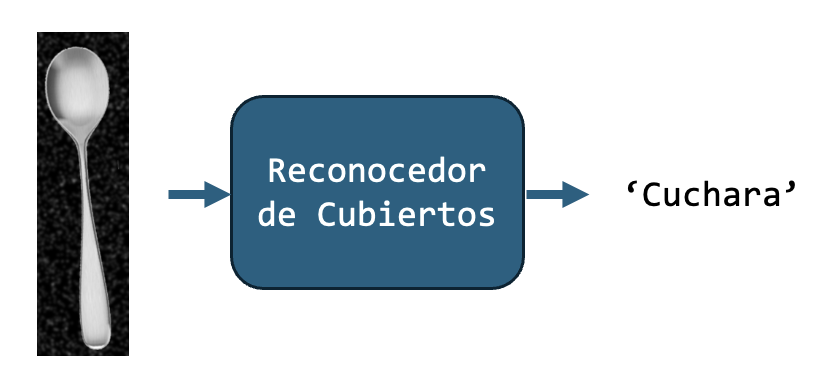

#IMPORTANTE: Cambiar el nombre del archivo

<font color='red'>ATENCIÓN: ANTES DE SEGUIR, CAMBIA EL NOMBRE DEL ARCHIVO ipynb INCLUYENDO TU RUT</font>

Ejemplo, si este ejercicio es el E03 tu RUT es 12.345.678-9, el nombre de este archivo debe cambiarse a "E03_12345678-9.ipynb". Para hacer esto debes hacer click arriba a la izquierda donde está el nombre del archivo y editarlo.


# PASO INICIAL

Ejecute estas celdas para cargar la librería Balu3. Esta librería se usará para las funciones que extraen las características geometricas basadas en los descriptores de Fourier y los momentos de Hu.


In [1]:
!git clone https://github.com/domingomery/balu3
!pip install ./balu3

Cloning into 'balu3'...
remote: Enumerating objects: 294, done.
remote: Counting objects: 100% (24/24), done.
remote: Compressing objects: 100% (16/16), done.
remote: Total 294 (delta 8), reused 19 (delta 6), pack-reused 270 (from 1)
Receiving objects: 100% (294/294), 76.98 KiB | 1.64 MiB/s, done.
Resolving deltas: 100% (166/166), done.
Processing ./balu3
  Preparing metadata (setup.py) ... done
  Created wheel for balu3: filename=balu3-1.0-py3-none-any.whl size=44315 sha256=cb49ff3c20de0a6bea1c2bb608449922dd7b0857cbc67416788772ff822083b7
  Stored in directory: /tmp/pip-ephem-wheel-cache-2fi93qx8/wheels/39/7d/19/68e9d64cf6f9ae0af8c95e8f83db81fa1e3b8d2f21e62b876f
Successfully built balu3


In [2]:
import numpy             as np
import matplotlib.pyplot as plt
from balu3.fx.geo       import fourierdes    # Fourier Descriptors
from balu3.fx.geo       import hugeo         # Hu Moments
from balu3.io.plots     import plot_features
from skimage.filters    import threshold_otsu
from scipy.ndimage      import binary_fill_holes
from skimage.morphology import remove_small_objects


In [3]:
def num2fixstr(x,d):
    st = '%0*d' % (d,x)
    return st

def imageload(prefix,num_class,digits_class,num_img,digits_img,sep='_',echo='off'):
  st   = prefix + num2fixstr(num_class,digits_class) + sep + num2fixstr(num_img,digits_img) + '.jpg'
  if echo == 'on':
    print('loading image '+st+'...')
  img    = plt.imread(st)
  return img


# PREGUNTA 01: CARGAR LA BASE DE DATOS

(2 puntos)

1.1 > (1 punto) Subir el archivo zip que está en

GitHub > clases > Cap02 > datos > cubiertos.zip

1.2 > (1 punto) Descomprimir el archivo 'cubiertos.zip', asegurarse que 300 las imágenes de la base de datos estén en la carpeta 'cubiertos'. Observe que el nombre de los archivos tiene el siguiente formato: 'C_x_nnn.jpg' donde 'x' es 1, 2, ó 3 si se trata de un tenedor, un cuchillo o una cuchara respectivamente, y 'nnn' es 001, 002, ... 100 para indexar las 100 imágenes de cada cubierto.



In [4]:
# Escriba código aquí
import zipfile
REPO = 'https://raw.githubusercontent.com/domingomery/pr/main/clases/'
!wget {REPO}PR02_Extraccion_de_Caracteristicas/datos/cubiertos.zip

# Open the zip file in read mode
with zipfile.ZipFile('cubiertos.zip', 'r') as zip_ref:
    # Extract all contents into a specific directory
    zip_ref.extractall('')

--2026-09-05 02:02:47--  https://raw.githubusercontent.com/domingomery/pr/main/clases/PR02_Extraccion_de_Caracteristicas/datos/cubiertos.zip
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.110.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 31238182 (30M) [application/zip]
Saving to: ‘cubiertos.zip’

cubiertos.zip       100%[===================>]  29.79M   113MB/s    in 0.3s    

2026-09-05 02:02:48 (113 MB/s) - ‘cubiertos.zip’ saved [31238182/31238182]



# PREGUNTA 02: PREPROCESAMIENTO

(5 puntos)

2.1 > (1 punto) Cargue en la variable 'I' la imagen 'cubiertos/C_3_010.jpg' y despliéguela.

2.2 > (1 punto) Usando la función 'threshold_otsu' de la librería 'skimage.filters' estime el umbral de segmentación y guárdelo en la variable 'th'

2.3 > (1 punto) Segmente la imagen 'I' usando el umbral 'th', y guarde la imagen binaria (segmentación) en la variable 'R0'. Despliegue la imagen 'R0'.

2.4 > (1 punto) Rellene los agujeros de la imagen 'R0' usando la función 'binary_fill_holes' de la librería 'scipy.ndimage' y guarde el resultado en la variable 'R1'. Despliegue la imagen 'R1'.

2.5 > (1 punto) Elimine las regiones de menos de 200 pixeles de la imagen 'R1' usando la función 'remove_small_objects' de la librería 'skimage.morphology' y guarde el resultado en la variable 'R2'. Despliegue la imagen 'R2'.

Observe que el último paso es necesario para eliminar una estructura muy pequeña, apenas perceptible ubicada aproximadamente en la posición (450,1050).



In [ ]:
def otsu_segmentation(img):


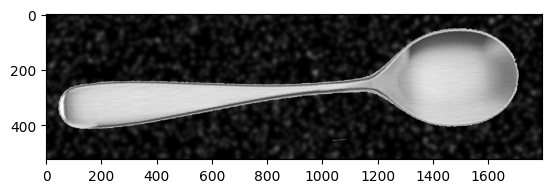

In [7]:
# Escriba código aquí
#2.1
I = plt.imread('cubiertos/C_3_010.jpg')
implot = plt.imshow(I,cmap='gray')

In [8]:
#2.2
th = threshold_otsu(I)

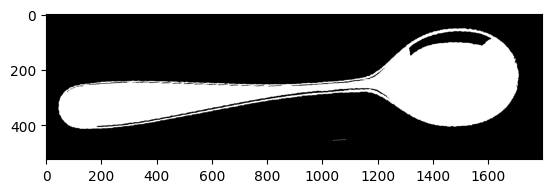

In [9]:
#2.3
R0 = I > th
implot = plt.imshow(R0,cmap='gray')

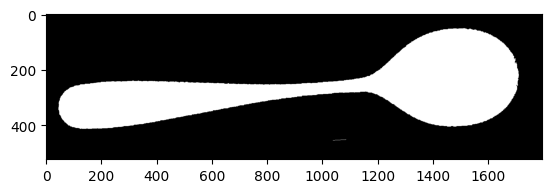

In [10]:
#2.4
R1 = binary_fill_holes(R0)
implot = plt.imshow(R1,cmap='gray')

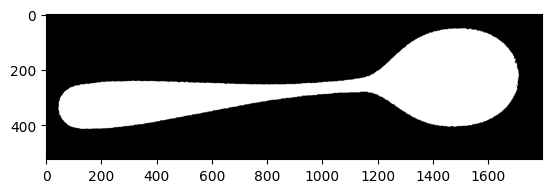

In [11]:
#2.5
R2 = remove_small_objects(R1, min_size=200)
implot = plt.imshow(R2,cmap='gray')

# PREGUNTA 03: EXTRACCIÓN DE CARACTERÍSTICAS GEOMÉTRICAS

(7 puntos)

3.1 > (2 puntos) Usando el código definido en la pregunta anterior, escriba una función que se llame 'segmenta' que tome como argumento la imagen I, y que devuelva como salida la imagen R3 <font color='red'>donde

R3 = R2*1</font> <font color='blue'>#ojo se multiplica por "1", no por "1.", ni por "1.0"</font>

3.2 (1 puntos) Usando la función del paso anterior, calcule R3 para la imagen 'cubiertos/C_1_015.jpg' y despliéguela.

3.3 (2 puntos) Usando la función 'fourierdes' de la librería 'balu3.fx.geo', calcule y despliegue los <font color='red'>16 descritores de Fourier</font> de la imagen binaria R3. Use los descriptores de Fourier sin normalizar.

3.4 (2 puntos) Usando la función 'hugeo' de la librería 'balu3.fx.geo', calcule y despliegue los <font color='red'>7 momentos de Hu</font> de la imagen binaria R3. Use los momentos de Hu sin normalizar.




In [12]:
#3.1
def segmenta(I):
    th = threshold_otsu(I)

    R0 = I > th

    R1 = binary_fill_holes(R0)

    R2 = remove_small_objects(R1, min_size=200)

    return R2*1

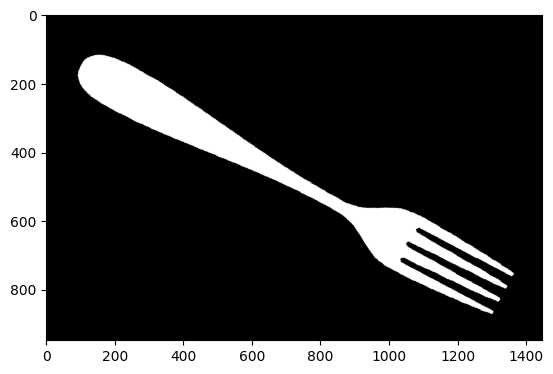

In [14]:
#3.2
I = plt.imread('cubiertos/C_1_015.jpg')
R3 = segmenta(I)
implot = plt.imshow(R3,cmap='gray')

In [16]:
#3.3
R3_fourier = fourierdes(R3)
print(R3_fourier)

[0.85791882 0.03948759 0.54546439 0.61701796 0.02639115 0.34367057
 0.97158076 0.64911485 0.41814464 0.13631487 0.14563586 0.04776991
 0.16444859 0.03422018 0.05850063 0.01971084]


In [17]:
#3.4
R3_hu = hugeo(R3)
print(R3_hu)

[1.41336812e+00 1.93243535e+00 6.48081141e-03 9.67317059e-03
 7.65887686e-05 1.34462664e-02 2.78705786e-07]


# PREGUNTA 04: EXTRACCIÓN PARA TODA LA BASE DE DATOS

(12 puntos)

4.1 > (12 puntos) Escriba un código que lea todas las imágenes de la base de datos (100 imágenes por cada clase), y que

a) segemente cada una de ellas (usando la función 'segmenta' de la pregunta anterior) y

b) extraiga los 16 descriptores de Fourier y 7 los momentos de Hu.

La salida debe ser

- una matriz 'X' de 100+100+100=300 filas por 16+7=23 columnas, y

- un vector 'y' de 300 elementos con 100 ceros, 100 unos y 100 dos, que indica la clase de cada una de las 300 imágenes.

Aquí el pseudo código:

- definir X como un arreglo de 300 x 26 elementos
- definir y como un arreglo de 300 elementos
- definir contador t = 0
- para cada clase (o sea para la clase 0, 1 y 2)
- > para cada imagen (o sea para 1, 2, ... 100)
- > > leer la imagen correspondiente
- > > segmentar la imagen
- > > calcular los descriptores de Fourier
- > > guardar en X[t,0:16] los descriptores de Fourier
- > > calcular los momentos de Hu
- > > guardar en X[t,16:23] los momentos de Hu
- > > guardar en y[t] la clase
- > > actualizar contador (t=t+1)


In [27]:
X = np.zeros((300, 23))
y = np.zeros(300, dtype=int)

t = 0
for clase in range(3):
    for num_img in range(1, 101):
        I  = imageload('cubiertos/C_', clase + 1, 1, num_img, 3)
        R3 = segmenta(I)

        X[t, 0:16]  = fourierdes(R3)
        X[t, 16:23] = hugeo(R3)
        y[t] = clase

        t += 1

print(X.shape)
print(y.shape)

(300, 23)
(300,)


# PREGUNTA 05: SPLIT TRAINING/TESTING

(4 puntos)

5.1 > (1 punto) Almacene en 'Xtrain' las primeras 80 muestras de cada clase almacenadas en 'X' (es decir 'Xtrain' debe tener 240x26 elementos).

5.2 > (1 punto) Almacene en 'Xtest' las últimas 20 muestras de cada clase almacenadas en 'X' (es decir 'Xtest' debe tener 60x26 elementos).

5.3 > (1 punto) Almacene en 'ytrain' las primeras 80 clases almacenadas en 'y' (es decir 'ytrain' debe tener 240 elementos: 80 ceros, 80 unos, 80 dos).

5.4 > (1 punto) Almacene en 'ytest' las últimas 20 clases almacenadas en 'y' (es decir 'ytest' debe tener 60 elementos: 20 ceros, 20 unos, 20 dos).


In [38]:
Xtrain = np.zeros((240, 23))
Xtest  = np.zeros((60, 23))
ytrain = np.zeros(240, dtype=int)
ytest  = np.zeros(60, dtype=int)

Xtrain = np.vstack((X[0:80, :], X[100:180, :], X[200:280, :]))
Xtest  = np.vstack((X[80:100, :], X[180:200, :], X[280:300, :]))

ytrain = np.hstack((y[0:80], y[100:180], y[200:280]))
ytest  = np.hstack((y[80:100], y[180:200], y[280:300]))

print(Xtrain.shape, ytrain.shape)
print(Xtest.shape, ytest.shape)

(240, 23) (240,)
(60, 23) (60,)


# PREGUNTA 06: SELECCIÓN Y ANÁLISIS

(6 puntos)

6.1 > (2 puntos) Almacene en 'Xs_train' el tercer momento de Hu y el primer descriptor de Fourier a partir de 'X_train', es decir 'Xs_train' debe tener 240x2 elementos.

6.2 > (4 puntos) Grafique el espacio de dos características de 'Xs_train'.

Observe que no hay que definir 'ys_train', porque sería igual a 'ytrain'.


(240, 2)


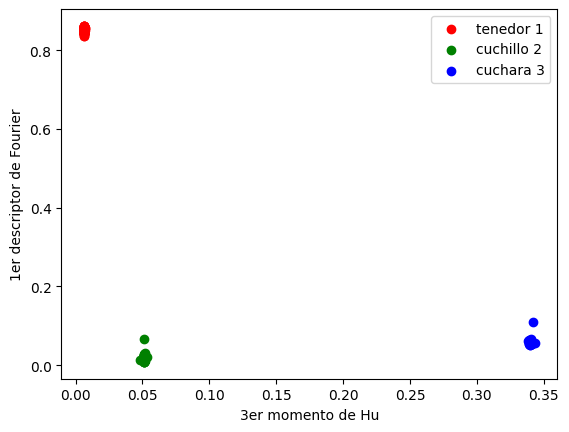

In [49]:
#6.1
Xs_train = np.column_stack((Xtrain[:, 18], Xtrain[:, 0]))
print(Xs_train.shape)

#6.2
plt.figure()
colores  = ['r', 'g', 'b']
etiquetas = ['tenedor 1', 'cuchillo 2', 'cuchara 3']
for clase in range(3):
    idx = ytrain == clase
    plt.scatter(Xs_train[idx, 0], Xs_train[idx, 1], c=colores[clase], label=etiquetas[clase])
plt.xlabel('3er momento de Hu')
plt.ylabel('1er descriptor de Fourier')
plt.legend()
plt.show()

# PREGUNTA 07: CLASIFICACIÓN DEL TESTING

(6 puntos)

7.1 > (1 puntos) Almacene en 'Xs_test' el primer momento de Hu y el tercer deescriptor de Fourier a partir de 'X_train', es decir 'Xs_test' debe tener 60x2 elementos.

7.2 > (5 puntos) A partir de la gráfica obtenida en el punto anterior, diseñe un clasificador. Escriba el código para este clasificador y almacene la clasificación de 'Xs_test' en la variable 'ys_test' de 60 elementos.

7.3 > (1 punto) Imprima los valores de 'ys_test' y de 'ytest', verifique visualmente que son iguales.


In [55]:
#7.1
Xs_test = np.column_stack((Xtest[:, 18], Xtest[:, 0]))
print(Xs_test.shape)

#7.2

def clasificador(Xs):
    n = Xs.shape[0]
    ys = np.zeros(n, dtype=int)
    for i in range(n):
        hu3 = Xs[i, 0]
        f1  = Xs[i, 1]
        if f1 > 0.4:
            ys[i] = 0
        elif hu3 < 0.2:
            ys[i] = 1
        else:
            ys[i] = 2
    return ys

ys_test = clasificador(Xs_test)

#7.3
print("ys_test:", ys_test)
print("ytest:  ", ytest)

(60, 2)
ys_test: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2]
ytest:   [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2]


# PREGUNTA 08: EVALUACIÓN

(5 puntos)

8.1 > (2 puntos) A partir de 'ytest' y 'ys_test' calcule la matriz de confusión 'C'.

8.2 > (2 puntos) grafique la matriz de confusión (puede usar la librería 'seaborn' y/o 'matplotlib')

8.3 > (1 puntos) A partir de 'C' calcule el 'Accuracy'.


[[20  0  0]
 [ 0 20  0]
 [ 0  0 20]]


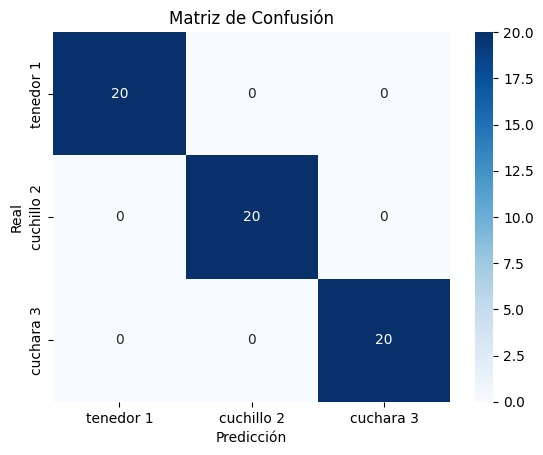

Accuracy: 1.0


In [56]:
#8.1
from sklearn.metrics import confusion_matrix
C = confusion_matrix(ytest, ys_test)
print(C)

#8.2
import seaborn as sns
plt.figure()
sns.heatmap(C, annot=True, fmt='d', cmap='Blues',
            xticklabels=etiquetas, yticklabels=etiquetas)
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de Confusión')
plt.show()

#8.3
accuracy = np.trace(C) / np.sum(C)
print("Accuracy:", accuracy)